# Urban Growth Likelihood Mapping


This notebook uses the Open Buildings Temporal dataset to rank where new buildings are most likely to appear in the following year.

The output is a **growth-likelihood map** — a ranked probability score per empty pixel — not an exact future prediction. Exact one-year construction is only partly predictable from building presence masks alone.


Packages are assumed to be installed. Install any missing package once in the environment and restart the kernel before running.

This cell imports libraries, fixes the random seed, defines city windows and sampling settings, and sets up folder paths. Each city entry is a small geographic crop — we sample patches from it rather than using the full global dataset. Cities are split at the city level, so test cities are completely unseen during training.


In [1]:
import hashlib
import json
import os
import random
import re
import time
import urllib.parse
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyproj
import rasterio
import requests
from scipy.ndimage import binary_dilation, distance_transform_edt
from rasterio.enums import Resampling
from rasterio.transform import Affine
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds
from shapely.geometry import Polygon, box
from shapely.ops import transform as shapely_transform
from tqdm.auto import tqdm

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

PROJECT_DIR = Path.cwd()
CACHE_DIR = PROJECT_DIR / "data" / "cache" / "open_buildings_temporal"
DATA_DIR = PROJECT_DIR / "data" / "processed" / "open_buildings_temporal"
MODEL_DIR = PROJECT_DIR / "models" / "open_buildings_temporal"
CACHE_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

BUCKET = "open-buildings-temporal-data"
DATASET_VERSION = "v1"
GCS_JSON_API = f"https://storage.googleapis.com/storage/v1/b/{BUCKET}/o"
GCS_PUBLIC_BASE = f"https://storage.googleapis.com/{BUCKET}/"

YEARS = list(range(2016, 2024))
INPUT_YEARS = YEARS[:-1]
TARGET_YEAR = YEARS[-1]
BAND_TO_READ = "building_presence"

CITY_IMAGE_SIZE = 1024
CITY_HALF_SIZE_DEGREES = 0.02
PATCH_SIZE = 128
TASK_NAME = "growth_2022_to_2023_v3_more_diverse_cities"
PATCHES_PER_CITY = 120
POSITIVE_PATCH_RATIO = 0.70
MIN_BUILT_SHARE_2023 = 0.01
MAX_BUILT_SHARE_2023 = 0.85
MIN_GROWTH_SHARE = 0.002
MIN_NEGATIVE_BUILT_SHARE_2022 = 0.02
MAX_ATTEMPTS_PER_CITY = PATCHES_PER_CITY * 180

REBUILD_TILE_INDEX = False
REBUILD_DATASET = False

AOI_CENTERS = {
    # Training cities: multiple regions and development patterns.
    "new_cairo": [30.0115, 31.5499],
    "accra": [5.6037, -0.1870],
    "nairobi": [-1.2864, 36.8172],
    "lagos": [6.5244, 3.3792],
    "addis_ababa": [8.9806, 38.7578],
    "dhaka": [23.8103, 90.4125],
    "delhi": [28.6139, 77.2090],
    "karachi": [24.8607, 67.0011],
    "chennai": [13.0827, 80.2707],
    "jakarta": [-6.2088, 106.8456],
    "ho_chi_minh": [10.8231, 106.6297],
    "lima": [-12.0464, -77.0428],
    "bogota": [4.7110, -74.0721],
    "quito": [-0.1807, -78.4678],
    "medellin": [6.2442, -75.5812],

    # Validation cities: used for model selection and the prediction cap.
    "manila": [14.5995, 120.9842],
    "phnom_penh": [11.5564, 104.9282],
    "kampala": [0.3476, 32.5825],
    "kigali": [-1.9441, 30.0619],
    "bangkok": [13.7563, 100.5018],

    # Test cities: held out until final evaluation.
    "mexico_city": [19.4326, -99.1332],
    "sao_paulo": [-23.5505, -46.6333],
    "dar_es_salaam": [-6.7924, 39.2083],
    "lahore": [31.5204, 74.3587],
    "hanoi": [21.0278, 105.8342],
}

CITY_SPLITS = {
    "new_cairo": "train",
    "accra": "train",
    "nairobi": "train",
    "lagos": "train",
    "addis_ababa": "train",
    "dhaka": "train",
    "delhi": "train",
    "karachi": "train",
    "chennai": "train",
    "jakarta": "train",
    "ho_chi_minh": "train",
    "lima": "train",
    "bogota": "train",
    "quito": "train",
    "medellin": "train",
    "manila": "val",
    "phnom_penh": "val",
    "kampala": "val",
    "kigali": "val",
    "bangkok": "val",
    "mexico_city": "test",
    "sao_paulo": "test",
    "dar_es_salaam": "test",
    "lahore": "test",
    "hanoi": "test",
}

CONFIG = {
    "task": TASK_NAME,
    "seed": SEED,
    "dataset_version": DATASET_VERSION,
    "band": BAND_TO_READ,
    "years": YEARS,
    "input_years": INPUT_YEARS,
    "target_year": TARGET_YEAR,
    "city_image_size": CITY_IMAGE_SIZE,
    "city_half_size_degrees": CITY_HALF_SIZE_DEGREES,
    "patch_size": PATCH_SIZE,
    "patches_per_city": PATCHES_PER_CITY,
    "min_built_share_2023": MIN_BUILT_SHARE_2023,
    "max_built_share_2023": MAX_BUILT_SHARE_2023,
    "positive_patch_ratio": POSITIVE_PATCH_RATIO,
    "min_growth_share": MIN_GROWTH_SHARE,
    "min_negative_built_share_2022": MIN_NEGATIVE_BUILT_SHARE_2022,
    "aoi_centers": AOI_CENTERS,
    "city_splits": CITY_SPLITS,
}
CONFIG_HASH = hashlib.md5(json.dumps(CONFIG, sort_keys=True).encode()).hexdigest()[:10]
TILE_INDEX_CONFIG = {
    "dataset_version": DATASET_VERSION,
    "band": BAND_TO_READ,
    "years": YEARS,
    "city_half_size_degrees": CITY_HALF_SIZE_DEGREES,
    "aoi_centers": AOI_CENTERS,
}
TILE_INDEX_HASH = hashlib.md5(json.dumps(TILE_INDEX_CONFIG, sort_keys=True).encode()).hexdigest()[:10]

TILE_INDEX_PATH = CACHE_DIR / f"tile_index_{TILE_INDEX_HASH}.csv"
DATASET_PATH = DATA_DIR / f"patches_{CONFIG_HASH}.npz"
CONFIG_PATH = DATA_DIR / f"config_{CONFIG_HASH}.json"
METADATA_PATH = DATA_DIR / f"metadata_{CONFIG_HASH}.json"
SMALL_UNET_MODEL_PATH = MODEL_DIR / f"small_unet_{CONFIG_HASH}.pt"
RESNET34_UNET_MODEL_PATH = MODEL_DIR / f"resnet34_unet_{CONFIG_HASH}.pt"
MODEL_PATHS = {
    "small_unet": SMALL_UNET_MODEL_PATH,
    "resnet34_unet": RESNET34_UNET_MODEL_PATH,
}

print("Dataset path:", DATASET_PATH)
print("Config hash:", CONFIG_HASH)
print("Tile index path:", TILE_INDEX_PATH)
print("Model paths:", MODEL_PATHS)


Dataset path: /Users/matas.mazvila/Notebooks/deep-learning-group-proj/data/processed/open_buildings_temporal/patches_e01f59a7c1.npz
Config hash: e01f59a7c1
Tile index path: /Users/matas.mazvila/Notebooks/deep-learning-group-proj/data/cache/open_buildings_temporal/tile_index_a3fc7a78d2.csv
Model paths: {'small_unet': PosixPath('/Users/matas.mazvila/Notebooks/deep-learning-group-proj/models/open_buildings_temporal/small_unet_e01f59a7c1.pt'), 'resnet34_unet': PosixPath('/Users/matas.mazvila/Notebooks/deep-learning-group-proj/models/open_buildings_temporal/resnet34_unet_e01f59a7c1.pt')}


GCS and GeoTIFF helpers. These find the public files that overlap our selected cities.

In [2]:
def aoi_box_for_city(city):
    lat, lon = AOI_CENTERS[city]
    return box(
        lon - CITY_HALF_SIZE_DEGREES,
        lat - CITY_HALF_SIZE_DEGREES,
        lon + CITY_HALF_SIZE_DEGREES,
        lat + CITY_HALF_SIZE_DEGREES,
    )


AOI_BOXES = {city: aoi_box_for_city(city) for city in AOI_CENTERS}


def list_gcs_objects(prefix):
    params = {
        "prefix": prefix,
        "fields": "items(name),nextPageToken",
        "maxResults": 1000,
    }
    while True:
        response = requests.get(GCS_JSON_API, params=params, timeout=60)
        response.raise_for_status()
        payload = response.json()
        for item in payload.get("items", []):
            yield item["name"]
        token = payload.get("nextPageToken")
        if not token:
            break
        params["pageToken"] = token


def gcs_object_to_https(object_name):
    return GCS_PUBLIC_BASE + urllib.parse.quote(object_name, safe="/")


def uri_to_https(uri):
    if uri.startswith("https://"):
        return uri
    if uri.startswith("gs://"):
        bucket_and_path = uri.removeprefix("gs://")
        bucket, object_name = bucket_and_path.split("/", 1)
        return f"https://storage.googleapis.com/{bucket}/{urllib.parse.quote(object_name, safe='/')}"
    return gcs_object_to_https(uri.lstrip("/"))


def manifest_cache_path(object_name):
    safe_name = object_name.replace("/", "__")
    return CACHE_DIR / "manifests" / safe_name


def load_manifest(object_name):
    cache_path = manifest_cache_path(object_name)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    if cache_path.exists():
        return json.loads(cache_path.read_text())
    response = requests.get(gcs_object_to_https(object_name), timeout=60)
    response.raise_for_status()
    payload = response.json()
    cache_path.write_text(json.dumps(payload))
    return payload


def year_from_manifest_name(name):
    match = re.search(r"_(20\d{2})_", name)
    return int(match.group(1)) if match else None


def manifest_matches_band(name):
    lower = name.lower()
    known_bands = ["building_presence", "building_height", "building_fractional_count"]
    if any(band in lower for band in known_bands):
        return BAND_TO_READ in lower
    return True


def tile_polygon_from_source(source):
    affine = source["affineTransform"]
    transform = Affine.translation(
        affine["translateX"], affine["translateY"]
    ) * Affine.scale(affine["scaleX"], affine["scaleY"])
    width = source["dimensions"]["width"]
    height = source["dimensions"]["height"]
    corners = [(0, 0), (width, 0), (width, height), (0, height)]
    return Polygon([transform * corner for corner in corners])


def first_uri_from_source(manifest, source):
    return uri_to_https(manifest["uriPrefix"] + source["uris"][0])


Build or load a cached tile index. This is the slow metadata scan, but it runs once per config.

In [3]:
def build_tile_index():
    if TILE_INDEX_PATH.exists() and not REBUILD_TILE_INDEX:
        print("Loading cached tile index:", TILE_INDEX_PATH)
        return pd.read_csv(TILE_INDEX_PATH)

    manifest_prefix = f"{DATASET_VERSION}/manifests/"
    manifest_objects = [
        name for name in list_gcs_objects(manifest_prefix)
        if year_from_manifest_name(name) in YEARS and manifest_matches_band(name)
    ]

    records = []
    for manifest_name in tqdm(manifest_objects, desc="Scanning manifests"):
        year = year_from_manifest_name(manifest_name)
        manifest = load_manifest(manifest_name)

        for tileset in manifest["tilesets"]:
            crs = tileset["crs"]
            transformer = pyproj.Transformer.from_crs("EPSG:4326", crs, always_xy=True)
            aoi_by_city = {
                city: shapely_transform(transformer.transform, geom)
                for city, geom in AOI_BOXES.items()
            }

            for source in tileset["sources"]:
                tile_poly = tile_polygon_from_source(source)
                for city, city_aoi in aoi_by_city.items():
                    if not tile_poly.intersects(city_aoi):
                        continue
                    records.append({
                        "city": city,
                        "split": CITY_SPLITS[city],
                        "year": year,
                        "crs": crs,
                        "url": first_uri_from_source(manifest, source),
                        "manifest": manifest_name,
                    })

    tile_index = pd.DataFrame(records).drop_duplicates(["city", "year", "url"])
    tile_index = tile_index.sort_values(["city", "year", "url"]).reset_index(drop=True)
    tile_index.to_csv(TILE_INDEX_PATH, index=False)
    return tile_index


tile_index = build_tile_index()
display(tile_index.groupby(["split", "city", "year"]).size().rename("tile_count").to_frame().head(40))
print("Tile rows:", len(tile_index))


Loading cached tile index: /Users/matas.mazvila/Notebooks/deep-learning-group-proj/data/cache/open_buildings_temporal/tile_index_a3fc7a78d2.csv


tile_count
split city          year            
test  dar_es_salaam 2016           2
                    2017           2
                    2018           2
                    2019           2
                    2020           2
                    2021           2
                    2022           2
                    2023           2
      hanoi         2016           4
                    2017           4
                    2018           4
                    2019           4
                    2020           4
                    2021           4
                    2022           4
                    2023           4
      lahore        2016           1
                    2017           1
                    2018           1
                    2019           1
                    2020           1
                    2021           1
                    2022           1
                    2023           1
      mexico_city   2016           5
                    2017           5
                    2018           5
                    2019           5
                    2020           5
                    2021           5
                    2022           5
                    2023           5
      sao_paulo     2016           3
                    2017           3
                    2018           3
                    2019           3
                    2020           3
                    2021           3
                    2022           3
                    2023           3

Tile rows: 544


Read one city window for all years, then sample local patches from that window.

In [4]:
def guess_band_index(src, band_name):
    descriptions = [desc or "" for desc in src.descriptions]
    for index, description in enumerate(descriptions, start=1):
        if band_name.lower() in description.lower():
            return index
    fallback = {
        "building_fractional_count": 1,
        "building_height": 2,
        "building_presence": 3,
    }
    return min(fallback.get(band_name, 1), src.count)


def read_aoi_from_url(url, aoi_geometry_wgs84, band_name=BAND_TO_READ, out_size=CITY_IMAGE_SIZE):
    with rasterio.Env(GDAL_DISABLE_READDIR_ON_OPEN="EMPTY_DIR"):
        with rasterio.open(url) as src:
            minx, miny, maxx, maxy = transform_bounds(
                "EPSG:4326", src.crs, *aoi_geometry_wgs84.bounds, densify_pts=21
            )
            window = from_bounds(minx, miny, maxx, maxy, transform=src.transform)
            window = window.round_offsets().round_lengths()
            band_index = guess_band_index(src, band_name)
            arr = src.read(
                band_index,
                window=window,
                out_shape=(out_size, out_size),
                resampling=Resampling.bilinear,
                boundless=True,
                fill_value=0,
            ).astype(np.float32)
    return np.nan_to_num(np.clip(arr, 0, 1), nan=0.0)


def read_city_year(city, year):
    rows = tile_index[(tile_index["city"] == city) & (tile_index["year"] == year)]
    if rows.empty:
        raise ValueError(f"No tile found for {city}, {year}.")

    arrays = []
    for url in rows["url"].tolist():
        try:
            arrays.append(read_aoi_from_url(url, AOI_BOXES[city]))
        except Exception as error:
            print(f"Skipping unreadable tile for {city} {year}: {error}")

    if not arrays:
        raise ValueError(f"No readable tiles for {city}, {year}.")
    return np.maximum.reduce(arrays)


def read_city_stack(city):
    arrays = []
    for year in YEARS:
        arrays.append(read_city_year(city, year))
    stack = np.stack(arrays, axis=0)
    return np.rint(stack * 255).astype(np.uint8)


def sample_patches_from_stack(city, stack):
    split = CITY_SPLITS[city]
    h, w = stack.shape[1:]
    positive_target = round(PATCHES_PER_CITY * POSITIVE_PATCH_RATIO)
    negative_target = PATCHES_PER_CITY - positive_target
    positive_patches = []
    negative_patches = []
    positive_metadata = []
    negative_metadata = []
    attempts = 0

    while (
        len(positive_patches) < positive_target or len(negative_patches) < negative_target
    ) and attempts < MAX_ATTEMPTS_PER_CITY:
        attempts += 1
        row = rng.integers(0, h - PATCH_SIZE + 1)
        col = rng.integers(0, w - PATCH_SIZE + 1)
        patch = stack[:, row:row + PATCH_SIZE, col:col + PATCH_SIZE]

        previous = patch[-2] >= 128
        target_presence = patch[-1] >= 128
        growth = np.logical_and(target_presence, ~previous)
        built_share_2022 = previous.mean()
        built_share_2023 = target_presence.mean()
        growth_share = growth.mean()

        if not (MIN_BUILT_SHARE_2023 <= built_share_2023 <= MAX_BUILT_SHARE_2023):
            continue

        info = {
            "city": city,
            "split": split,
            "row": int(row),
            "col": int(col),
            "built_share_2022": float(built_share_2022),
            "built_share_2023": float(built_share_2023),
            "growth_share_2022_to_2023": float(growth_share),
            "has_growth": bool(growth_share >= MIN_GROWTH_SHARE),
        }

        if growth_share >= MIN_GROWTH_SHARE and len(positive_patches) < positive_target:
            positive_patches.append(patch)
            positive_metadata.append(info)
        elif (
            growth_share < MIN_GROWTH_SHARE
            and built_share_2022 >= MIN_NEGATIVE_BUILT_SHARE_2022
            and len(negative_patches) < negative_target
        ):
            negative_patches.append(patch)
            negative_metadata.append(info)

    patches = positive_patches + negative_patches
    metadata = positive_metadata + negative_metadata
    if len(patches) < PATCHES_PER_CITY:
        print(f"Warning: only kept {len(patches)} patches for {city} after {attempts} attempts.")
    if not patches:
        raise ValueError(f"No usable patches for {city}.")

    order = rng.permutation(len(patches))
    patches = [patches[i] for i in order]
    metadata = [metadata[i] for i in order]
    return np.stack(patches, axis=0), metadata


Build or load the patch dataset. The setup uses 15 training cities, 5 validation cities, and 5 held-out test cities across multiple regions.


In [5]:
def build_patch_dataset():
    if DATASET_PATH.exists() and CONFIG_PATH.exists() and not REBUILD_DATASET:
        print("Loading existing dataset:", DATASET_PATH)
        return np.load(DATASET_PATH, allow_pickle=True), pd.DataFrame(json.loads(METADATA_PATH.read_text()))

    all_x = []
    all_y = []
    all_target_presence = []
    all_city = []
    all_split = []
    all_metadata = []

    for city in tqdm(list(AOI_CENTERS), desc="Building city datasets"):
        print(f"\nReading {city} ({CITY_SPLITS[city]})")
        try:
            city_stack = read_city_stack(city)
            patches, metadata = sample_patches_from_stack(city, city_stack)
        except Exception as error:
            print(f"Skipping {city}: {error}")
            continue

        x_city = patches[:, :-1]
        previous_presence = patches[:, -2:-1] >= 128
        target_presence_city = patches[:, -1:] >= 128
        y_city = np.logical_and(target_presence_city, ~previous_presence).astype(np.uint8) * 255
        all_x.append(x_city)
        all_y.append(y_city)
        all_target_presence.append(patches[:, -1:])
        all_city.extend([city] * len(patches))
        all_split.extend([CITY_SPLITS[city]] * len(patches))
        all_metadata.extend(metadata)

    if not all_x:
        raise RuntimeError("No patches were created. Check network access and city coverage.")

    x = np.concatenate(all_x, axis=0)
    y = np.concatenate(all_y, axis=0)
    target_presence = np.concatenate(all_target_presence, axis=0)
    city = np.array(all_city)
    split = np.array(all_split)
    sample_id = np.arange(len(x))

    np.savez_compressed(
        DATASET_PATH,
        x=x,
        y=y,
        target_presence=target_presence,
        city=city,
        split=split,
        sample_id=sample_id,
        input_years=np.array(INPUT_YEARS),
        target_year=np.array([TARGET_YEAR]),
        target_name=np.array(["new_buildings_2022_to_2023"]),
    )
    CONFIG_PATH.write_text(json.dumps(CONFIG, indent=2))
    METADATA_PATH.write_text(json.dumps(all_metadata, indent=2))

    print("Saved dataset:", DATASET_PATH)
    return np.load(DATASET_PATH, allow_pickle=True), pd.DataFrame(all_metadata)


data, metadata_df = build_patch_dataset()
x = data["x"]
y = data["y"]
target_presence = data["target_presence"]
city = data["city"]
split = data["split"]

split_counts = pd.Series(split).value_counts().to_dict()
missing_splits = [name for name in ["train", "val", "test"] if split_counts.get(name, 0) == 0]
if missing_splits:
    raise RuntimeError(f"Missing samples for split(s): {missing_splits}. Check skipped cities above.")

dataset_summary = (
    metadata_df
    .groupby("split")
    .agg(
        samples=("city", "size"),
        cities=("city", "nunique"),
        mean_2022_built_share=("built_share_2022", "mean"),
        mean_2022_to_2023_growth=("growth_share_2022_to_2023", "mean"),
        share_of_patches_with_some_growth=("has_growth", "mean"),
    )
    .reset_index()
)

display(compact_display(dataset_summary) if "compact_display" in globals() else dataset_summary.round(3))
print(f"Loaded x={x.shape}, y={y.shape}. A growth patch means at least {MIN_GROWTH_SHARE:.1%} of pixels became newly built, not that the whole patch is growth.")


Loading existing dataset: /Users/matas.mazvila/Notebooks/deep-learning-group-proj/data/processed/open_buildings_temporal/patches_e01f59a7c1.npz


,split,samples,cities,mean_2022_built_share,mean_2022_to_2023_growth,share_of_patches_with_some_growth
0,test,450,5,0.311,0.032,0.933
1,train,1542,15,0.236,0.032,0.817
2,val,480,5,0.281,0.033,0.875


Loaded x=(2472, 7, 128, 128), y=(2472, 1, 128, 128). A growth patch means at least 0.2% of pixels became newly built, not that the whole patch is growth.


The sampling is not a global random sample — patches are drawn from fixed city windows. Train, validation, and test cities come from different regions, and test cities are held out completely from training.


## Sanity Check: Is The Final Year Quieter?
This checks whether 2022->2023 has less growth than earlier one-year transitions. It matters because a quieter final year makes overprediction more likely.


In [6]:
presence_stack = np.concatenate([x, target_presence], axis=1)
year_pair_labels = [f"{start}->{end}" for start, end in zip(YEARS[:-1], YEARS[1:])]

growth_rows = []
for sample_idx in range(len(presence_stack)):
    for pair_idx, label in enumerate(year_pair_labels):
        previous = presence_stack[sample_idx, pair_idx] >= 128
        current = presence_stack[sample_idx, pair_idx + 1] >= 128
        growth_share = float(np.logical_and(current, ~previous).mean())
        growth_rows.append({
            "split": split[sample_idx],
            "year_pair": label,
            "growth_pixel_share": growth_share,
            "has_growth": bool(growth_share >= MIN_GROWTH_SHARE),
        })

yearly_growth_df = pd.DataFrame(growth_rows)
target_pair = "2022->2023"
historical_df = yearly_growth_df[yearly_growth_df["year_pair"] != target_pair]
target_df = yearly_growth_df[yearly_growth_df["year_pair"] == target_pair]

sanity_summary_df = (
    historical_df.groupby("split")
    .agg(historical_growth=("growth_pixel_share", "mean"))
    .join(target_df.groupby("split").agg(final_year_growth=("growth_pixel_share", "mean")))
    .reset_index()
)
sanity_summary_df["final_year_vs_history"] = sanity_summary_df["final_year_growth"] / sanity_summary_df["historical_growth"]

display(compact_display(sanity_summary_df) if "compact_display" in globals() else sanity_summary_df.round(3))
ratio_min = sanity_summary_df["final_year_vs_history"].min()
ratio_max = sanity_summary_df["final_year_vs_history"].max()
print(f"2022->2023 has about {ratio_min:.0%}-{ratio_max:.0%} as much growth as earlier one-year transitions, depending on split.")


,split,historical_growth,final_year_growth,final_year_vs_history
0,test,0.046,0.032,0.710
1,train,0.042,0.032,0.745
2,val,0.045,0.033,0.737


2022->2023 has about 71%-74% as much growth as earlier one-year transitions, depending on split.


This check explains a major difficulty: the final year has less growth than earlier rolling years. That makes unrestricted pixel prediction prone to false alarms, so the binary map is limited to the growth rate observed in validation cities.


Create rolling one-year training examples and the nearest-building baseline.

Each training row is: current-year building map -> next-year new-building mask. The baseline is intentionally simple: empty pixels closer to existing buildings receive higher growth scores.


In [7]:
if "presence_stack" not in globals():
    presence_stack = np.concatenate([x, target_presence], axis=1)
    year_pair_labels = [f"{start}->{end}" for start, end in zip(YEARS[:-1], YEARS[1:])]


def current_existing_for_pair(sample_idx, pair_idx):
    return presence_stack[int(sample_idx), int(pair_idx)] >= 128


def growth_target_for_pair(sample_idx, pair_idx):
    previous = current_existing_for_pair(sample_idx, pair_idx)
    current = presence_stack[int(sample_idx), int(pair_idx) + 1] >= 128
    return np.logical_and(current, ~previous).astype(np.uint8) * 255


def targets_for_rows(rows_df):
    targets = [
        growth_target_for_pair(int(row.sample_id), int(row.pair_idx))
        for row in rows_df.itertuples(index=False)
    ]
    return np.stack(targets, axis=0)[:, None]


def make_rolling_index():
    rows = []
    for sample_idx in range(len(presence_stack)):
        for pair_idx, label in enumerate(year_pair_labels):
            target = growth_target_for_pair(sample_idx, pair_idx)
            growth_share = float((target >= 128).mean())
            rows.append({
                "sample_id": sample_idx,
                "pair_idx": pair_idx,
                "current_year": YEARS[pair_idx],
                "target_year": YEARS[pair_idx + 1],
                "year_pair": label,
                "split": split[sample_idx],
                "city": city[sample_idx],
                "growth_pixel_share": growth_share,
                "has_growth": bool(growth_share >= MIN_GROWTH_SHARE),
                "is_final_pair": label == "2022->2023",
            })
    return pd.DataFrame(rows)


def balance_training_rows(rows_df, positive_ratio=0.55):
    balanced = []
    local_rng = np.random.default_rng(SEED)
    for _, group in rows_df.groupby(["city", "year_pair"]):
        positives = group[group["has_growth"]]
        negatives = group[~group["has_growth"]]
        if len(positives) == 0 or len(negatives) == 0:
            keep_n = min(len(group), 60)
            balanced.append(group.sample(keep_n, random_state=SEED))
            continue
        neg_keep = len(negatives)
        pos_keep = min(len(positives), int(np.ceil(neg_keep * positive_ratio / (1 - positive_ratio))))
        balanced.append(negatives)
        balanced.append(positives.sample(pos_keep, random_state=SEED))
    out = pd.concat(balanced, ignore_index=True)
    return out.iloc[local_rng.permutation(len(out))].reset_index(drop=True)


def nearest_building_scores_for_rows(rows_df):
    """Simple score map: closer empty pixels are more likely to become buildings."""
    scores = []
    for row in rows_df.itertuples(index=False):
        sample_idx = int(row.sample_id)
        pair_idx = int(row.pair_idx)
        existing = current_existing_for_pair(sample_idx, pair_idx)
        if existing.any():
            distance = distance_transform_edt(~existing).astype(np.float32)
            score = 1.0 / (1.0 + distance)
            # Many pixels can have exactly the same distance. Tiny seeded jitter avoids artificial stripe patterns.
            tie_rng = np.random.default_rng(SEED + sample_idx * 100 + pair_idx)
            score = score + tie_rng.uniform(0, 1e-6, size=score.shape).astype(np.float32)
            score[existing] = 0.0
        else:
            score = np.zeros(existing.shape, dtype=np.float32)
        scores.append(score)
    return np.stack(scores, axis=0)[:, None].astype(np.float32)


def mask_existing_scores(score_array, rows_df):
    masked = score_array.copy().astype(np.float32)
    for local_i, row in enumerate(rows_df.itertuples(index=False)):
        existing = current_existing_for_pair(row.sample_id, row.pair_idx)
        masked[local_i, 0, existing] = 0.0
    return masked


def capped_prediction_from_scores(score_array, rows_df, cap_share):
    """Keep only the top-scoring empty pixels, using one expected growth cap for every patch."""
    preds = np.zeros_like(score_array, dtype=np.uint8)
    pixels_per_patch = score_array.shape[-1] * score_array.shape[-2]
    k = int(round(float(cap_share) * pixels_per_patch))
    if k <= 0:
        return preds

    masked_scores = mask_existing_scores(score_array, rows_df)
    for local_i, row in enumerate(rows_df.itertuples(index=False)):
        existing = current_existing_for_pair(row.sample_id, row.pair_idx)
        candidate_mask = ~existing
        candidate_scores = masked_scores[local_i, 0][candidate_mask]
        if candidate_scores.size == 0:
            continue
        keep_k = min(k, candidate_scores.size)
        chosen_in_candidates = np.argpartition(candidate_scores, -keep_k)[-keep_k:]
        flat_candidate_indices = np.flatnonzero(candidate_mask.ravel())
        chosen_flat = flat_candidate_indices[chosen_in_candidates]
        pred_flat = preds[local_i, 0].ravel()
        pred_flat[chosen_flat] = 255
    return preds


def average_precision_from_scores(score_array, target_uint8):
    y_true = (target_uint8 >= 128).ravel().astype(bool)
    y_score = score_array.ravel().astype(np.float64)
    positives = int(y_true.sum())
    if positives == 0:
        return np.nan

    order = np.argsort(-y_score, kind="mergesort")
    y_true = y_true[order]
    y_score = y_score[order]

    distinct = np.where(np.diff(y_score))[0]
    threshold_idxs = np.r_[distinct, y_true.size - 1]
    true_positives = np.cumsum(y_true)[threshold_idxs]
    predicted_positives = threshold_idxs + 1
    precision = true_positives / predicted_positives
    recall = true_positives / positives
    recall_step = np.diff(np.r_[0.0, recall])
    return float(np.sum(recall_step * precision))


def binary_growth_metrics(pred_uint8, target_uint8, threshold=128):
    pred = pred_uint8 >= threshold
    target = target_uint8 >= threshold
    tp = np.logical_and(pred, target).sum()
    fp = np.logical_and(pred, ~target).sum()
    fn = np.logical_and(~pred, target).sum()
    union = np.logical_or(pred, target).sum()
    precision = tp / (tp + fp) if (tp + fp) else 0.0
    recall = tp / (tp + fn) if (tp + fn) else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
    return {
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "iou": float(tp / union) if union else 0.0,
        "target_pixel_share": float(target.mean()),
        "predicted_pixel_share": float(pred.mean()),
    }


def candidate_stats_for_rows(target_uint8, rows_df, cap_share):
    total_growth = 0
    total_candidate_pixels = 0
    max_hits_at_cap = 0
    pixels_per_patch = target_uint8.shape[-1] * target_uint8.shape[-2]
    cap_pixels = int(round(float(cap_share) * pixels_per_patch))

    for local_i, row in enumerate(rows_df.itertuples(index=False)):
        existing = current_existing_for_pair(row.sample_id, row.pair_idx)
        target = target_uint8[local_i, 0] >= 128
        candidate_pixels = int((~existing).sum())
        growth_pixels = int(target.sum())
        total_candidate_pixels += candidate_pixels
        total_growth += growth_pixels
        max_hits_at_cap += min(growth_pixels, min(cap_pixels, candidate_pixels))

    candidate_growth_share = total_growth / total_candidate_pixels if total_candidate_pixels else np.nan
    max_recall_at_cap = max_hits_at_cap / total_growth if total_growth else np.nan
    return candidate_growth_share, max_recall_at_cap


def score_at_cap_metrics(score_array, rows_df, model_name, subset_name, cap_share):
    target = targets_for_rows(rows_df)
    clean_scores = mask_existing_scores(score_array, rows_df)
    cap_pred = capped_prediction_from_scores(clean_scores, rows_df, cap_share)
    binary = binary_growth_metrics(cap_pred, target)
    candidate_base_rate, max_recall = candidate_stats_for_rows(target, rows_df, cap_share)
    precision_at_cap = binary["precision"]
    return {
        "model": model_name,
        "subset": subset_name,
        "samples": len(rows_df),
        "pr_auc": average_precision_from_scores(clean_scores, target),
        "precision_at_cap": precision_at_cap,
        "recall_at_cap": binary["recall"],
        "max_recall_at_cap": max_recall,
        "lift_vs_random": float(precision_at_cap / candidate_base_rate) if candidate_base_rate else np.nan,
        "f1_at_cap": binary["f1"],
        "iou_at_cap": binary["iou"],
        "target_pixel_share": binary["target_pixel_share"],
        "candidate_growth_share": float(candidate_base_rate),
        "predicted_pixel_share": binary["predicted_pixel_share"],
        "cap_share": float(cap_share),
    }


def compact_display(df, decimals=3):
    return df.copy().round(decimals)


rolling_df = make_rolling_index()
train_roll_df = balance_training_rows(rolling_df[rolling_df["split"] == "train"])
val_roll_df = rolling_df[(rolling_df["split"] == "val") & (~rolling_df["is_final_pair"])].reset_index(drop=True)
val_final_df = rolling_df[(rolling_df["split"] == "val") & (rolling_df["is_final_pair"])].reset_index(drop=True)
test_final_df = rolling_df[(rolling_df["split"] == "test") & (rolling_df["is_final_pair"])].reset_index(drop=True)


# Convert probability maps to binary maps by predicting the validation growth rate.
# This avoids an arbitrary probability threshold and keeps predicted growth amount realistic.
EXPECTED_GROWTH_SHARE = float(val_final_df["growth_pixel_share"].mean())
print(f"Prediction cap from validation cities: {EXPECTED_GROWTH_SHARE:.3%} of pixels per patch")

val_nearest_scores = nearest_building_scores_for_rows(val_final_df)
test_nearest_scores = nearest_building_scores_for_rows(test_final_df)
baseline_results = pd.DataFrame([
    score_at_cap_metrics(val_nearest_scores, val_final_df, "nearest_building_baseline", "val final", EXPECTED_GROWTH_SHARE),
    score_at_cap_metrics(test_nearest_scores, test_final_df, "nearest_building_baseline", "test final", EXPECTED_GROWTH_SHARE),
])
print(f"Rolling train rows: {len(train_roll_df):,}; validation rows: {len(val_roll_df):,}; final test rows: {len(test_final_df):,}.")


Prediction cap from validation cities: 3.328% of pixels per patch
Rolling train rows: 5,162; validation rows: 2,880; final test rows: 450.


The prediction cap shown above is the mean 2022→2023 growth rate in validation cities. It limits binary growth predictions to a realistic pixel budget and avoids systematic overprediction. PR-AUC ranks all empty pixels without any threshold, so it is not affected by the cap.


Two models are compared against the nearest-building baseline. The small U-Net trains from scratch on 4-channel binary feature maps. The ResNet34 U-Net uses a deeper ImageNet-pretrained encoder, with its first layer re-initialized for 4-channel input — full weight transfer is limited because the inputs are processed binary presence maps, not natural photographs.


In [8]:
try:
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from torch.utils.data import DataLoader, Dataset
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        "PyTorch is required for the model cells. Install torch/torchvision once in your active environment."
    ) from error

try:
    from torchvision.models import ResNet34_Weights, resnet34
except ModuleNotFoundError as error:
    raise ModuleNotFoundError(
        "torchvision is required for the ResNet34 encoder. Install torchvision once in your active environment."
    ) from error


def seed_torch(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_torch()
mps_available = hasattr(torch.backends, "mps") and torch.backends.mps.is_available()
device = torch.device(
    "mps" if mps_available
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
print("Device:", device)


MODEL_EDGE_RADIUS = 3
MODEL_IN_CHANNELS = 4
print("Model input channels:", MODEL_IN_CHANNELS)


def rolling_features_for_pair(sample_idx, pair_idx):
    current = presence_stack[sample_idx, pair_idx] >= 128
    if pair_idx == 0:
        previous_growth = np.zeros_like(current)
    else:
        previous = presence_stack[sample_idx, pair_idx - 1] >= 128
        previous_growth = np.logical_and(current, ~previous)
    edge_zone = np.logical_and(binary_dilation(current, iterations=MODEL_EDGE_RADIUS), ~current)
    year_channel = np.full(current.shape, pair_idx / max(len(YEARS) - 2, 1), dtype=np.float32)
    return np.stack([
        current.astype(np.float32),
        previous_growth.astype(np.float32),
        edge_zone.astype(np.float32),
        year_channel,
    ], axis=0)


class RollingGrowthDataset(Dataset):
    def __init__(self, rows_df):
        self.rows_df = rows_df.reset_index(drop=True)

    def __len__(self):
        return len(self.rows_df)

    def __getitem__(self, item):
        row = self.rows_df.iloc[item]
        sample_idx = int(row["sample_id"])
        pair_idx = int(row["pair_idx"])
        x_tensor = torch.from_numpy(rolling_features_for_pair(sample_idx, pair_idx))
        target = growth_target_for_pair(sample_idx, pair_idx).astype(np.float32)[None] / 255.0
        y_tensor = torch.from_numpy(target)
        return x_tensor, y_tensor


class ConvBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x_input):
        return self.net(x_input)


class SmallUNet(nn.Module):
    def __init__(self, in_channels=MODEL_IN_CHANNELS, base_channels=24):
        super().__init__()
        self.enc1 = ConvBlock(in_channels, base_channels)
        self.enc2 = ConvBlock(base_channels, base_channels * 2)
        self.bottleneck = ConvBlock(base_channels * 2, base_channels * 4)
        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(base_channels * 4, base_channels * 2)
        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(base_channels * 2, base_channels)
        self.out = nn.Conv2d(base_channels, 1, kernel_size=1)

    def forward(self, x_input):
        enc1 = self.enc1(x_input)
        enc2 = self.enc2(F.max_pool2d(enc1, 2))
        bottleneck = self.bottleneck(F.max_pool2d(enc2, 2))
        dec2 = self.up2(bottleneck)
        dec2 = self.dec2(torch.cat([dec2, enc2], dim=1))
        dec1 = self.up1(dec2)
        dec1 = self.dec1(torch.cat([dec1, enc1], dim=1))
        return self.out(dec1)


def adapt_resnet_first_conv(conv, in_channels):
    new_conv = nn.Conv2d(
        in_channels,
        conv.out_channels,
        kernel_size=conv.kernel_size,
        stride=conv.stride,
        padding=conv.padding,
        bias=conv.bias is not None,
    )
    with torch.no_grad():
        old_weight = conv.weight
        old_channels = old_weight.shape[1]
        if in_channels == old_channels:
            new_conv.weight.copy_(old_weight)
        else:
            repeated_weight = old_weight.mean(dim=1, keepdim=True).repeat(1, in_channels, 1, 1)
            channels_to_copy = min(old_channels, in_channels)
            repeated_weight[:, :channels_to_copy] = old_weight[:, :channels_to_copy]
            repeated_weight *= old_channels / in_channels
            new_conv.weight.copy_(repeated_weight)
        if conv.bias is not None:
            new_conv.bias.copy_(conv.bias)
    return new_conv


def make_resnet34_backbone(in_channels=MODEL_IN_CHANNELS, pretrained=True):
    loaded_pretrained = False
    if pretrained:
        try:
            backbone = resnet34(weights=ResNet34_Weights.DEFAULT)
            loaded_pretrained = True
        except Exception as error:
            print(f"ImageNet weights unavailable for ResNet34 ({type(error).__name__}: {error}). Using random encoder weights.")
            backbone = resnet34(weights=None)
    else:
        backbone = resnet34(weights=None)
    backbone.conv1 = adapt_resnet_first_conv(backbone.conv1, in_channels)
    return backbone, loaded_pretrained


class ResNet34UNet(nn.Module):
    def __init__(self, in_channels=MODEL_IN_CHANNELS, pretrained=True):
        super().__init__()
        backbone, loaded_pretrained = make_resnet34_backbone(in_channels=in_channels, pretrained=pretrained)
        self.loaded_pretrained_encoder = loaded_pretrained
        self.stem = nn.Sequential(backbone.conv1, backbone.bn1, backbone.relu)
        self.maxpool = backbone.maxpool
        self.layer1 = backbone.layer1
        self.layer2 = backbone.layer2
        self.layer3 = backbone.layer3
        self.layer4 = backbone.layer4

        self.up4 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec4 = ConvBlock(512, 256)
        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec3 = ConvBlock(256, 128)
        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(128, 64)
        self.up1 = nn.ConvTranspose2d(64, 64, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(128, 64)
        self.up0 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec0 = ConvBlock(32, 32)
        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x_input):
        stem = self.stem(x_input)          # 64x64
        enc1 = self.layer1(self.maxpool(stem))  # 32x32
        enc2 = self.layer2(enc1)           # 16x16
        enc3 = self.layer3(enc2)           # 8x8
        enc4 = self.layer4(enc3)           # 4x4

        dec4 = self.dec4(torch.cat([self.up4(enc4), enc3], dim=1))
        dec3 = self.dec3(torch.cat([self.up3(dec4), enc2], dim=1))
        dec2 = self.dec2(torch.cat([self.up2(dec3), enc1], dim=1))
        dec1 = self.dec1(torch.cat([self.up1(dec2), stem], dim=1))
        dec0 = self.dec0(self.up0(dec1))
        return self.out(dec0)


def build_growth_model(model_name, pretrained_encoder=False):
    if model_name == "small_unet":
        return SmallUNet(in_channels=MODEL_IN_CHANNELS)
    if model_name == "resnet34_unet":
        return ResNet34UNet(in_channels=MODEL_IN_CHANNELS, pretrained=pretrained_encoder)
    raise ValueError(f"Unknown model: {model_name}")


Device: mps
Model input channels: 4


Train the neural models and plot train/validation loss. Both models use the same rows, target, loss, cap, and evaluation setup.


Training rows: 5162 | validation rows: 2880 | final test rows: 450
Growth pixels in training targets: 4.16%; positive class weight: 4.80

Training small U-Net
epoch 01 | train 1.0950 | val 0.9674 | lr 3.0e-04
epoch 05 | train 0.8357 | val 0.7991 | lr 3.0e-04
epoch 10 | train 0.8022 | val 0.7917 | lr 3.0e-04
epoch 15 | train 0.7750 | val 0.7519 | lr 1.5e-04
epoch 20 | train 0.7568 | val 0.7564 | lr 7.5e-05
Early stopping after 21 epochs.
Best validation loss: 0.7519 at epoch 15.
Saved best model: /Users/matas.mazvila/Notebooks/deep-learning-group-proj/models/open_buildings_temporal/small_unet_e01f59a7c1.pt
Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /Users/matas.mazvila/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:10<00:00, 8.34MB/s]



Training ResNet34 U-Net | ImageNet encoder weights: loaded
epoch 01 | train 1.1380 | val 1.0427 | lr 1.0e-04
epoch 05 | train 0.8230 | val 0.7911 | lr 1.0e-04
epoch 10 | train 0.7298 | val 0.7798 | lr 5.0e-05
Early stopping after 12 epochs.
Best validation loss: 0.7761 at epoch 6.
Saved best model: /Users/matas.mazvila/Notebooks/deep-learning-group-proj/models/open_buildings_temporal/resnet34_unet_e01f59a7c1.pt


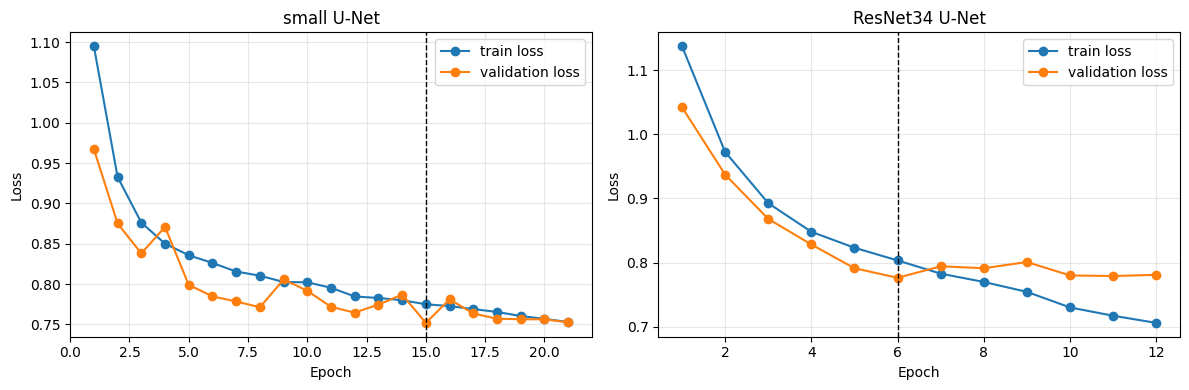

In [9]:
EPOCHS = 30
PATIENCE = 6
MIN_DELTA = 1e-4
VERBOSE_TRAINING = False

MODEL_SPECS = [
    {
        "name": "small_unet",
        "label": "small U-Net",
        "path": MODEL_PATHS["small_unet"],
        "batch_size": 16,
        "learning_rate": 3e-4,
        "pretrained_encoder": False,
    },
    {
        "name": "resnet34_unet",
        "label": "ResNet34 U-Net",
        "path": MODEL_PATHS["resnet34_unet"],
        "batch_size": 8,
        "learning_rate": 1e-4,
        "pretrained_encoder": True,
    },
]

positive_ratio = (targets_for_rows(train_roll_df) >= 128).mean()
pos_weight_value = float(np.clip(np.sqrt((1 - positive_ratio) / max(positive_ratio, 1e-6)), 1.0, 8.0))
bce_loss = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(pos_weight_value, device=device))

print(f"Training rows: {len(train_roll_df)} | validation rows: {len(val_roll_df)} | final test rows: {len(test_final_df)}")
print(f"Growth pixels in training targets: {positive_ratio:.2%}; positive class weight: {pos_weight_value:.2f}")


def tversky_loss_from_logits(logits, target, alpha=0.75, beta=0.25, smooth=1.0):
    probs = torch.sigmoid(logits)
    tp = (probs * target).sum(dim=(1, 2, 3))
    fp = (probs * (1 - target)).sum(dim=(1, 2, 3))
    fn = ((1 - probs) * target).sum(dim=(1, 2, 3))
    score = (tp + smooth) / (tp + alpha * fp + beta * fn + smooth)
    return 1 - score.mean()


def criterion(logits, target):
    return bce_loss(logits, target) + 0.7 * tversky_loss_from_logits(logits, target)


def run_epoch(model, loader, optimizer=None):
    train_mode = optimizer is not None
    model.train(train_mode)
    losses = []
    for xb, yb in loader:
        xb = xb.to(device)
        yb = yb.to(device)
        with torch.set_grad_enabled(train_mode):
            logits = model(xb)
            loss = criterion(logits, yb)
            if train_mode:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()
        losses.append(float(loss.detach().cpu()))
    return float(np.mean(losses))


def train_growth_model(spec):
    seed_torch(SEED)
    train_loader = DataLoader(
        RollingGrowthDataset(train_roll_df),
        batch_size=spec["batch_size"],
        shuffle=True,
        num_workers=0,
        generator=torch.Generator().manual_seed(SEED),
    )
    val_loader = DataLoader(
        RollingGrowthDataset(val_roll_df),
        batch_size=spec["batch_size"],
        shuffle=False,
        num_workers=0,
    )

    model = build_growth_model(spec["name"], pretrained_encoder=spec["pretrained_encoder"]).to(device)
    optimizer = torch.optim.AdamW(model.parameters(), lr=spec["learning_rate"], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

    if spec["name"] == "resnet34_unet":
        status = "loaded" if getattr(model, "loaded_pretrained_encoder", False) else "not loaded"
        print(f"\nTraining {spec['label']} | ImageNet encoder weights: {status}")
    else:
        print(f"\nTraining {spec['label']}")

    history = []
    best_val_loss = float("inf")
    epochs_without_improvement = 0
    for epoch in range(1, EPOCHS + 1):
        train_loss = run_epoch(model, train_loader, optimizer=optimizer)
        val_loss = run_epoch(model, val_loader, optimizer=None)
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]["lr"]
        history.append({"model": spec["name"], "epoch": epoch, "train_loss": train_loss, "val_loss": val_loss, "lr": current_lr})

        if VERBOSE_TRAINING or epoch == 1 or epoch % 5 == 0:
            print(f"epoch {epoch:02d} | train {train_loss:.4f} | val {val_loss:.4f} | lr {current_lr:.1e}")

        if val_loss < best_val_loss - MIN_DELTA:
            best_val_loss = val_loss
            epochs_without_improvement = 0
            torch.save({
                "model_state_dict": model.state_dict(),
                "config": CONFIG,
                "config_hash": CONFIG_HASH,
                "history": history,
                "task": "rolling_one_year_growth",
                "model_name": spec["name"],
                "model_label": spec["label"],
                "model_edge_radius": MODEL_EDGE_RADIUS,
                "loaded_pretrained_encoder": bool(getattr(model, "loaded_pretrained_encoder", False)),
            }, spec["path"])
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= PATIENCE:
                print(f"Early stopping after {epoch} epochs.")
                break

    history_df = pd.DataFrame(history)
    best_row = history_df.loc[history_df["val_loss"].idxmin()]
    print(f"Best validation loss: {best_row['val_loss']:.4f} at epoch {int(best_row['epoch'])}.")
    print("Saved best model:", spec["path"])
    return history_df


model_histories = {spec["name"]: train_growth_model(spec) for spec in MODEL_SPECS}

fig, axes = plt.subplots(1, len(MODEL_SPECS), figsize=(6 * len(MODEL_SPECS), 4), squeeze=False)
for ax, spec in zip(axes[0], MODEL_SPECS):
    history_df = model_histories[spec["name"]]
    best_row = history_df.loc[history_df["val_loss"].idxmin()]
    ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train loss")
    ax.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="validation loss")
    ax.axvline(int(best_row["epoch"]), color="black", linestyle="--", linewidth=1)
    ax.set_title(spec["label"])
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.grid(True, alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()


## Results

Load the best saved checkpoints and evaluate all three models. The table shows the nearest-building baseline, small U-Net, and ResNet34 U-Net on the same metrics so the comparison is direct.


,model,subset,pr_auc,precision_at_cap,recall_at_cap,f1_at_cap,lift_vs_empty_random,true_growth_share,predicted_growth_share
0,nearest_building_baseline,val final,0.164,0.155,0.155,0.155,3.356,0.033,0.033
1,nearest_building_baseline,test final,0.157,0.154,0.158,0.156,3.275,0.032,0.033
2,small_unet,val final,0.306,0.308,0.308,0.308,6.647,0.033,0.033
3,small_unet,test final,0.309,0.314,0.322,0.318,6.673,0.032,0.033
4,resnet34_unet,val final,0.296,0.302,0.302,0.302,6.524,0.033,0.033
5,resnet34_unet,test final,0.298,0.303,0.311,0.307,6.446,0.032,0.033


small U-Net on held-out test cities: PR-AUC 0.309 vs 0.157 for the nearest-building baseline; F1 at cap 0.318.
ResNet34 U-Net on held-out test cities: PR-AUC 0.298 vs 0.157 for the nearest-building baseline; F1 at cap 0.307.
Best neural model by test PR-AUC: small_unet.


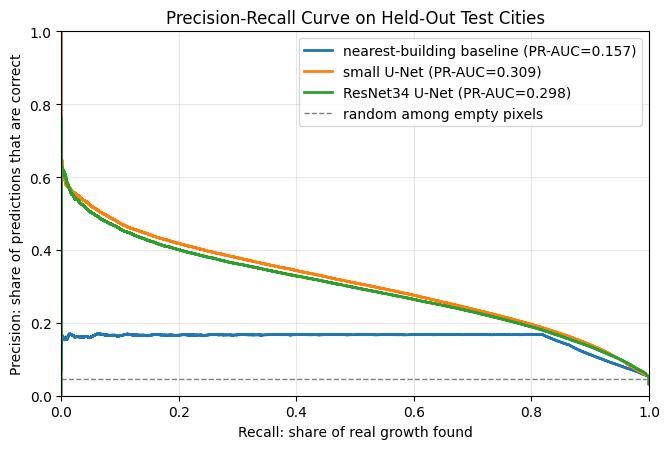

In [10]:
def predict_model_prob(model, rows_df, batch_size=32):
    loader = DataLoader(RollingGrowthDataset(rows_df), batch_size=batch_size, shuffle=False, num_workers=0)
    preds = []
    model.eval()
    with torch.no_grad():
        for xb, _ in loader:
            xb = xb.to(device)
            probs = torch.sigmoid(model(xb)).detach().cpu().numpy().astype(np.float32)
            preds.append(probs)
    return np.concatenate(preds, axis=0)


def load_trained_model(spec):
    checkpoint = torch.load(spec["path"], map_location=device)
    model = build_growth_model(spec["name"], pretrained_encoder=False).to(device)
    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    return model, checkpoint


def precision_recall_curve_from_scores(score_array, target_uint8):
    y_true = (target_uint8 >= 128).ravel().astype(bool)
    y_score = score_array.ravel().astype(np.float64)
    positives = int(y_true.sum())
    if positives == 0:
        return np.array([0.0]), np.array([1.0])

    order = np.argsort(-y_score, kind="mergesort")
    y_true = y_true[order]
    tp = np.cumsum(y_true)
    rank = np.arange(1, len(y_true) + 1)
    precision = tp / rank
    recall = tp / positives
    return recall, precision


def plot_precision_recall_curves(curve_specs, title, random_precision):
    fig, ax = plt.subplots(figsize=(6.8, 4.6))
    for label, scores, target in curve_specs:
        recall, precision = precision_recall_curve_from_scores(scores, target)
        auc = average_precision_from_scores(scores, target)
        ax.plot(recall, precision, label=f"{label} (PR-AUC={auc:.3f})", linewidth=2)
    ax.axhline(random_precision, color="gray", linestyle="--", linewidth=1, label="random among empty pixels")
    ax.set_title(title)
    ax.set_xlabel("Recall: share of real growth found")
    ax.set_ylabel("Precision: share of predictions that are correct")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.grid(True, alpha=0.3)
    ax.legend()
    plt.tight_layout()
    plt.show()


trained_models = {}
model_probability_maps = {}
model_results = []
for spec in MODEL_SPECS:
    trained_model, checkpoint = load_trained_model(spec)
    trained_models[spec["name"]] = trained_model
    val_prob = mask_existing_scores(predict_model_prob(trained_model, val_final_df, batch_size=spec["batch_size"]), val_final_df)
    test_prob = mask_existing_scores(predict_model_prob(trained_model, test_final_df, batch_size=spec["batch_size"]), test_final_df)
    model_probability_maps[spec["name"]] = {"val final": val_prob, "test final": test_prob}
    model_results.extend([
        score_at_cap_metrics(val_prob, val_final_df, spec["name"], "val final", EXPECTED_GROWTH_SHARE),
        score_at_cap_metrics(test_prob, test_final_df, spec["name"], "test final", EXPECTED_GROWTH_SHARE),
    ])

results = pd.concat([baseline_results, pd.DataFrame(model_results)], ignore_index=True)

display_results = results.rename(columns={
    "target_pixel_share": "true_growth_share",
    "candidate_growth_share": "empty_pixel_growth_share",
    "predicted_pixel_share": "predicted_growth_share",
    "cap_share": "growth_cap_share",
    "lift_vs_random": "lift_vs_empty_random",
})
main_result_columns = [
    "model", "subset", "pr_auc", "precision_at_cap", "recall_at_cap", "f1_at_cap",
    "lift_vs_empty_random", "true_growth_share", "predicted_growth_share",
]
display(compact_display(display_results[main_result_columns]))

main_test = display_results[display_results["subset"] == "test final"].set_index("model")
base = main_test.loc["nearest_building_baseline"]
for spec in MODEL_SPECS:
    row = main_test.loc[spec["name"]]
    print(
        f"{spec['label']} on held-out test cities: PR-AUC {row['pr_auc']:.3f} "
        f"vs {base['pr_auc']:.3f} for the nearest-building baseline; "
        f"F1 at cap {row['f1_at_cap']:.3f}."
    )

best_model_name = main_test.loc[[spec["name"] for spec in MODEL_SPECS], "pr_auc"].idxmax()
print(f"Best neural model by test PR-AUC: {best_model_name}.")

# PR curve for the held-out final test cities.
test_targets = targets_for_rows(test_final_df)
test_candidate_rate, _ = candidate_stats_for_rows(test_targets, test_final_df, EXPECTED_GROWTH_SHARE)
curve_specs = [("nearest-building baseline", test_nearest_scores, test_targets)]
for spec in MODEL_SPECS:
    curve_specs.append((spec["label"], model_probability_maps[spec["name"]]["test final"], test_targets))
plot_precision_recall_curves(
    curve_specs,
    title="Precision-Recall Curve on Held-Out Test Cities",
    random_precision=test_candidate_rate,
)


# Keep final-year arrays for the visualization cells.
model_predictions_at_cap = {}
model_probabilities_full = {}
for spec in MODEL_SPECS:
    model_predictions_at_cap[spec["name"]] = np.zeros_like(y)
    model_probabilities_full[spec["name"]] = np.zeros(y.shape, dtype=np.float32)

nearest_baseline_pred = np.zeros_like(y)
for subset_name, rows_df, nearest_scores in [
    ("val final", val_final_df, val_nearest_scores),
    ("test final", test_final_df, test_nearest_scores),
]:
    nearest_pred = capped_prediction_from_scores(nearest_scores, rows_df, EXPECTED_GROWTH_SHARE)
    model_preds = {
        spec["name"]: capped_prediction_from_scores(model_probability_maps[spec["name"]][subset_name], rows_df, EXPECTED_GROWTH_SHARE)
        for spec in MODEL_SPECS
    }
    for local_i, row in enumerate(rows_df.itertuples(index=False)):
        sample_idx = int(row.sample_id)
        nearest_baseline_pred[sample_idx] = nearest_pred[local_i]
        for spec in MODEL_SPECS:
            model_name = spec["name"]
            model_probabilities_full[model_name][sample_idx] = model_probability_maps[model_name][subset_name][local_i]
            model_predictions_at_cap[model_name][sample_idx] = model_preds[model_name][local_i]



The test-city rows are the main result. PR-AUC measures ranking quality across all pixels without a threshold; precision, recall, and F1 use the validation-based growth cap for the binary map.

The small U-Net clearly outperforms the nearest-building baseline. The ResNet34 U-Net does not improve over the small U-Net. This suggests the bottleneck is the signal available in building presence maps, not model capacity.


## Citywide Evaluation

This checks whether the models generalize to uniformly sampled patches from held-out test cities, not only to the growth-focused patches used in the main evaluation.


In [11]:
RUN_CITYWIDE_EVAL = True
CITYWIDE_PATCHES_PER_TEST_CITY = 80
CITYWIDE_EVAL_PATH = DATA_DIR / f"citywide_random_test_{CONFIG_HASH}_{CITYWIDE_PATCHES_PER_TEST_CITY}.npz"


def sample_uniform_patches_from_stack(city_name, stack, n_patches):
    local_rng = np.random.default_rng(SEED + sum(ord(ch) for ch in city_name))
    h, w = stack.shape[1:]
    patches = []
    rows = []
    for _ in range(n_patches):
        row = int(local_rng.integers(0, h - PATCH_SIZE + 1))
        col = int(local_rng.integers(0, w - PATCH_SIZE + 1))
        patch = stack[:, row:row + PATCH_SIZE, col:col + PATCH_SIZE]
        previous = patch[-2] >= 128
        target = patch[-1] >= 128
        growth = np.logical_and(target, ~previous)
        patches.append(patch)
        rows.append({
            "city": city_name,
            "split": "test_citywide",
            "row": row,
            "col": col,
            "built_share_2022": float(previous.mean()),
            "growth_share_2022_to_2023": float(growth.mean()),
        })
    return np.stack(patches, axis=0), rows


def build_or_load_citywide_eval():
    if CITYWIDE_EVAL_PATH.exists():
        cached = np.load(CITYWIDE_EVAL_PATH, allow_pickle=True)
        metadata = pd.DataFrame(json.loads(cached["metadata_json"].item()))
        return cached["stack"], cached["city"], metadata

    all_patches = []
    all_city = []
    all_metadata = []
    for city_name in [name for name, split_name in CITY_SPLITS.items() if split_name == "test"]:
        city_stack = read_city_stack(city_name)
        patches, rows = sample_uniform_patches_from_stack(city_name, city_stack, CITYWIDE_PATCHES_PER_TEST_CITY)
        all_patches.append(patches)
        all_city.extend([city_name] * len(patches))
        all_metadata.extend(rows)

    stack = np.concatenate(all_patches, axis=0)
    city_names = np.array(all_city)
    np.savez_compressed(
        CITYWIDE_EVAL_PATH,
        stack=stack,
        city=city_names,
        metadata_json=np.array(json.dumps(all_metadata)),
    )
    return stack, city_names, pd.DataFrame(all_metadata)


def stack_features_for_pair(stack_array, sample_idx, pair_idx):
    current = stack_array[sample_idx, pair_idx] >= 128
    if pair_idx == 0:
        previous_growth = np.zeros_like(current)
    else:
        previous = stack_array[sample_idx, pair_idx - 1] >= 128
        previous_growth = np.logical_and(current, ~previous)
    edge_zone = np.logical_and(binary_dilation(current, iterations=MODEL_EDGE_RADIUS), ~current)
    year_channel = np.full(current.shape, pair_idx / max(len(YEARS) - 2, 1), dtype=np.float32)
    return np.stack([
        current.astype(np.float32),
        previous_growth.astype(np.float32),
        edge_zone.astype(np.float32),
        year_channel,
    ], axis=0)


def stack_targets_for_pair(stack_array, pair_idx):
    previous = stack_array[:, pair_idx] >= 128
    current = stack_array[:, pair_idx + 1] >= 128
    return np.logical_and(current, ~previous).astype(np.uint8)[:, None] * 255


def stack_nearest_building_scores(stack_array, pair_idx):
    scores = []
    for sample_idx in range(len(stack_array)):
        existing = stack_array[sample_idx, pair_idx] >= 128
        if existing.any():
            distance = distance_transform_edt(~existing).astype(np.float32)
            score = 1.0 / (1.0 + distance)
            tie_rng = np.random.default_rng(SEED + 50000 + sample_idx * 100 + pair_idx)
            score = score + tie_rng.uniform(0, 1e-6, size=score.shape).astype(np.float32)
            score[existing] = 0.0
        else:
            score = np.zeros(existing.shape, dtype=np.float32)
        scores.append(score)
    return np.stack(scores, axis=0)[:, None].astype(np.float32)


def stack_mask_existing_scores(score_array, stack_array, pair_idx):
    masked = score_array.copy().astype(np.float32)
    for sample_idx in range(len(stack_array)):
        existing = stack_array[sample_idx, pair_idx] >= 128
        masked[sample_idx, 0, existing] = 0.0
    return masked


def stack_capped_prediction(score_array, stack_array, pair_idx, cap_share):
    preds = np.zeros_like(score_array, dtype=np.uint8)
    pixels_per_patch = score_array.shape[-1] * score_array.shape[-2]
    cap_pixels = int(round(float(cap_share) * pixels_per_patch))
    if cap_pixels <= 0:
        return preds
    masked_scores = stack_mask_existing_scores(score_array, stack_array, pair_idx)
    for sample_idx in range(len(stack_array)):
        existing = stack_array[sample_idx, pair_idx] >= 128
        candidate_mask = ~existing
        candidate_scores = masked_scores[sample_idx, 0][candidate_mask]
        if candidate_scores.size == 0:
            continue
        keep_k = min(cap_pixels, candidate_scores.size)
        chosen_in_candidates = np.argpartition(candidate_scores, -keep_k)[-keep_k:]
        flat_candidate_indices = np.flatnonzero(candidate_mask.ravel())
        preds[sample_idx, 0].ravel()[flat_candidate_indices[chosen_in_candidates]] = 255
    return preds


def stack_candidate_stats(target_uint8, stack_array, pair_idx, cap_share):
    total_growth = 0
    total_candidate_pixels = 0
    max_hits_at_cap = 0
    pixels_per_patch = target_uint8.shape[-1] * target_uint8.shape[-2]
    cap_pixels = int(round(float(cap_share) * pixels_per_patch))
    for sample_idx in range(len(stack_array)):
        existing = stack_array[sample_idx, pair_idx] >= 128
        target = target_uint8[sample_idx, 0] >= 128
        candidate_pixels = int((~existing).sum())
        growth_pixels = int(target.sum())
        total_candidate_pixels += candidate_pixels
        total_growth += growth_pixels
        max_hits_at_cap += min(growth_pixels, min(cap_pixels, candidate_pixels))
    candidate_growth_share = total_growth / total_candidate_pixels if total_candidate_pixels else np.nan
    max_recall = max_hits_at_cap / total_growth if total_growth else np.nan
    return candidate_growth_share, max_recall


def stack_score_metrics(score_array, stack_array, model_name, cap_share, pair_idx=6):
    target = stack_targets_for_pair(stack_array, pair_idx)
    clean_scores = stack_mask_existing_scores(score_array, stack_array, pair_idx)
    pred = stack_capped_prediction(clean_scores, stack_array, pair_idx, cap_share)
    binary = binary_growth_metrics(pred, target)
    candidate_base_rate, max_recall = stack_candidate_stats(target, stack_array, pair_idx, cap_share)
    precision = binary["precision"]
    return {
        "model": model_name,
        "eval_set": "uniform test-city patches",
        "samples": len(stack_array),
        "pr_auc": average_precision_from_scores(clean_scores, target),
        "precision_at_cap": precision,
        "recall_at_cap": binary["recall"],
        "f1_at_cap": binary["f1"],
        "max_recall_at_cap": max_recall,
        "lift_vs_empty_random": precision / candidate_base_rate if candidate_base_rate else np.nan,
        "true_growth_share": binary["target_pixel_share"],
        "predicted_growth_share": binary["predicted_pixel_share"],
    }


if RUN_CITYWIDE_EVAL:
    try:
        citywide_stack, citywide_city, citywide_metadata = build_or_load_citywide_eval()
        citywide_dataset = torch.utils.data.TensorDataset(
            torch.from_numpy(np.stack([
                stack_features_for_pair(citywide_stack, i, len(YEARS) - 2)
                for i in range(len(citywide_stack))
            ]).astype(np.float32))
        )
        citywide_loader = DataLoader(citywide_dataset, batch_size=16, shuffle=False, num_workers=0)
        citywide_nearest = stack_nearest_building_scores(citywide_stack, len(YEARS) - 2)
        result_rows = [
            stack_score_metrics(citywide_nearest, citywide_stack, "nearest_building_baseline", EXPECTED_GROWTH_SHARE),
        ]
        for spec in MODEL_SPECS:
            citywide_probs = []
            trained_model = trained_models[spec["name"]]
            trained_model.eval()
            with torch.no_grad():
                for (xb,) in citywide_loader:
                    probs = torch.sigmoid(trained_model(xb.to(device))).detach().cpu().numpy().astype(np.float32)
                    citywide_probs.append(probs)
            citywide_probs = np.concatenate(citywide_probs, axis=0)
            citywide_probs = stack_mask_existing_scores(citywide_probs, citywide_stack, len(YEARS) - 2)
            result_rows.append(stack_score_metrics(citywide_probs, citywide_stack, spec["name"], EXPECTED_GROWTH_SHARE))
        citywide_results = pd.DataFrame(result_rows)
        print(f"Uniform citywide patches: {len(citywide_stack)} total; mean true growth share = {citywide_metadata['growth_share_2022_to_2023'].mean():.2%}")
        display(compact_display(citywide_results[[
            "model", "samples", "pr_auc", "precision_at_cap", "recall_at_cap", "f1_at_cap",
            "lift_vs_empty_random", "true_growth_share", "predicted_growth_share",
        ]]))
        citywide_compare = citywide_results.set_index("model")
        base = citywide_compare.loc["nearest_building_baseline"]
        for spec in MODEL_SPECS:
            row = citywide_compare.loc[spec["name"]]
            print(
                f"On random held-out city patches, {spec['label']} PR-AUC is {row['pr_auc']:.3f} "
                f"vs {base['pr_auc']:.3f} for the nearest-building baseline."
            )
    except Exception as error:
        print(f"Skipped citywide random evaluation: {error}")
else:
    print("Citywide random evaluation skipped. Set RUN_CITYWIDE_EVAL = True to run it.")


Uniform citywide patches: 400 total; mean true growth share = 3.57%


,model,samples,pr_auc,precision_at_cap,recall_at_cap,f1_at_cap,lift_vs_empty_random,true_growth_share,predicted_growth_share
0,nearest_building_baseline,400,0.158,0.161,0.150,0.155,3.008,0.036,0.033
1,small_unet,400,0.305,0.334,0.312,0.323,6.248,0.036,0.033
2,resnet34_unet,400,0.296,0.325,0.303,0.313,6.067,0.036,0.033


On random held-out city patches, small U-Net PR-AUC is 0.305 vs 0.158 for the nearest-building baseline.
On random held-out city patches, ResNet34 U-Net PR-AUC is 0.296 vs 0.158 for the nearest-building baseline.


The uniform random check is a safeguard against cherry-picking. If the neural models still beat the nearest-building baseline here, the result is not only caused by growth-focused patch sampling.


## Qualitative Results

One patch per held-out test city is shown — the patch with the most actual growth in that city. This gives a concrete view of where each model is right and wrong across different urban contexts.


Visualized test cities: dar_es_salaam, hanoi, lahore, mexico_city, sao_paulo


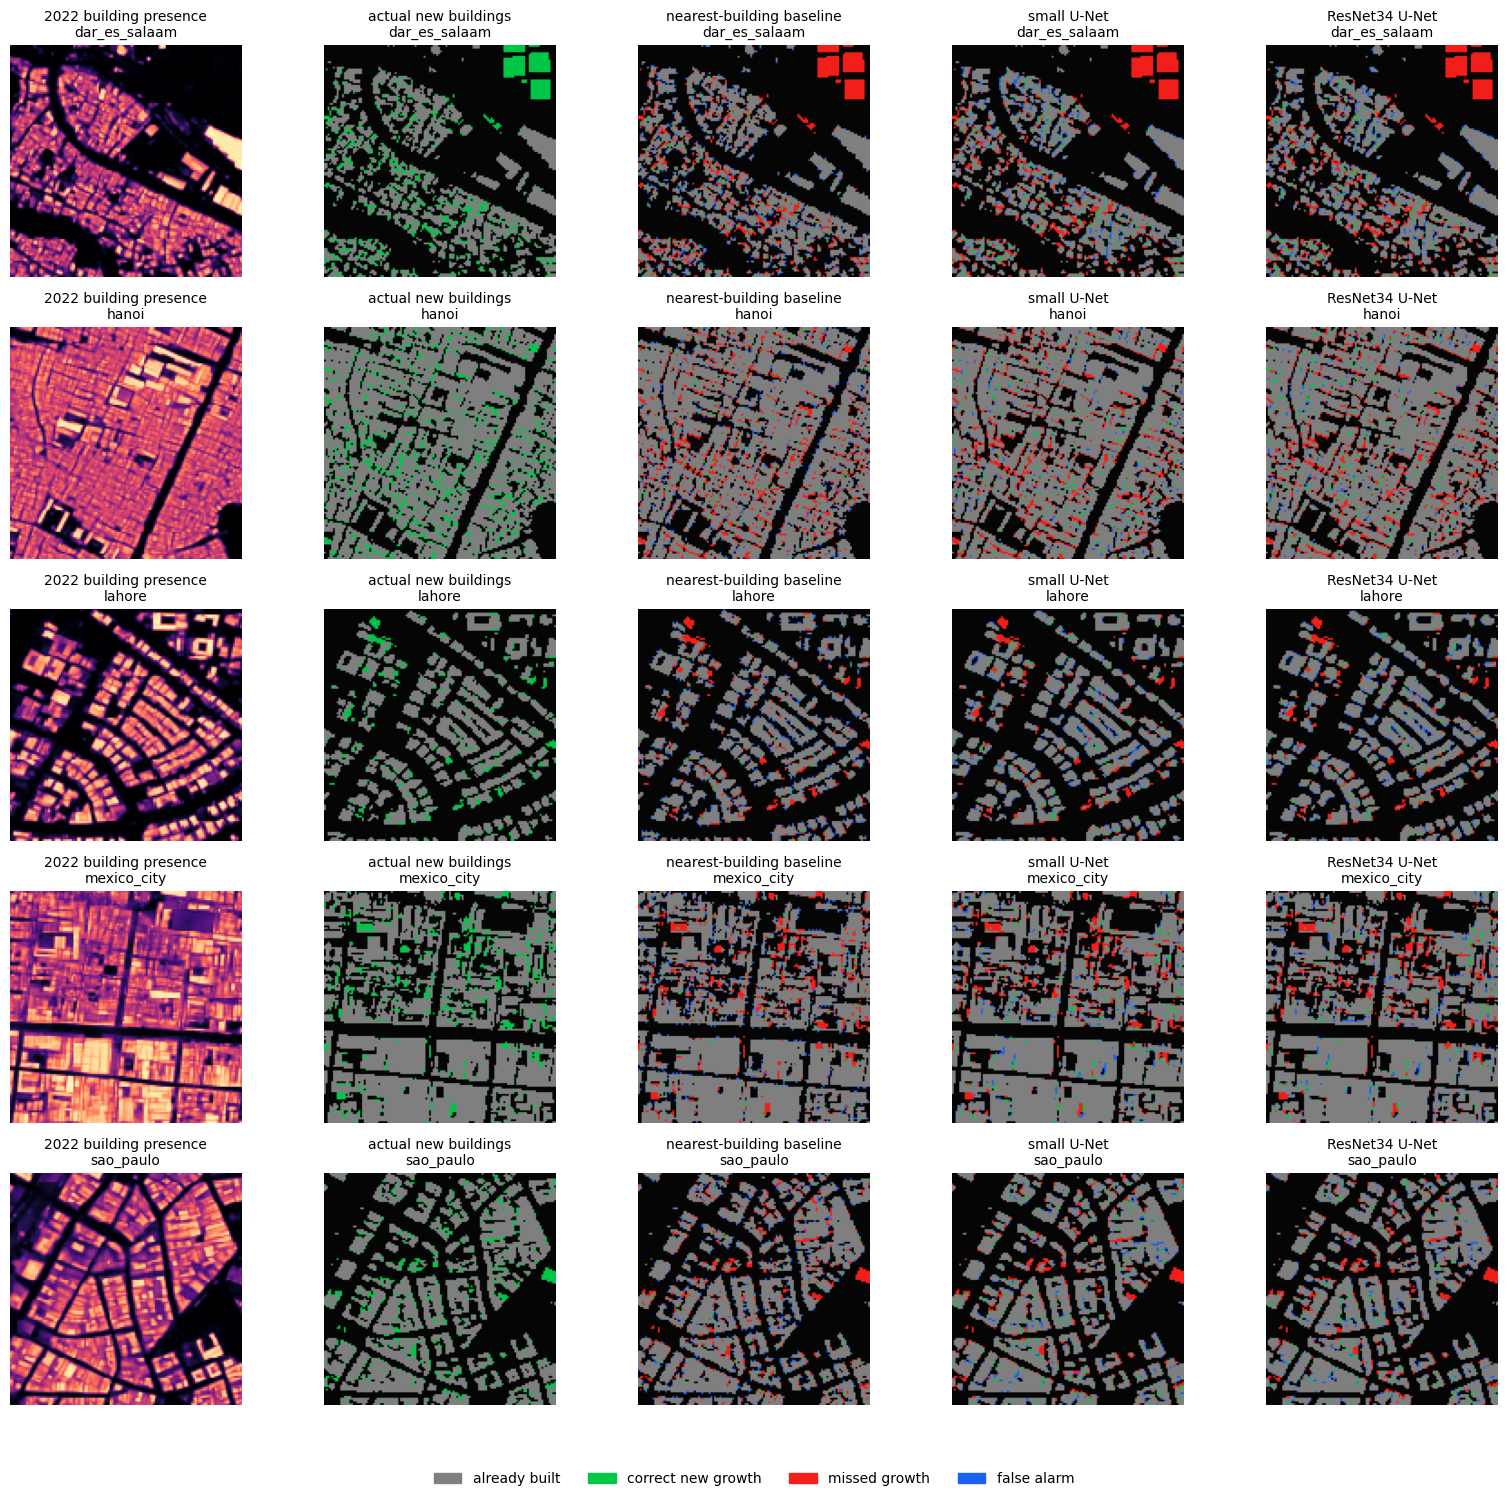

In [12]:
from matplotlib.patches import Patch

COLOR_EMPTY = np.array([0.02, 0.02, 0.02], dtype=np.float32)
COLOR_EXISTING = np.array([0.50, 0.50, 0.50], dtype=np.float32)
COLOR_CORRECT = np.array([0.00, 0.78, 0.28], dtype=np.float32)
COLOR_MISSED = np.array([0.95, 0.12, 0.10], dtype=np.float32)
COLOR_FALSE = np.array([0.10, 0.38, 0.95], dtype=np.float32)


def growth_error_rgb(existing_uint8, target_growth_uint8, pred_growth_uint8):
    existing = existing_uint8 >= 128
    target_growth = target_growth_uint8 >= 128
    pred_growth = pred_growth_uint8 >= 128
    correct = np.logical_and(target_growth, pred_growth)
    missed = np.logical_and(target_growth, ~pred_growth)
    false_alarm = np.logical_and(pred_growth, ~target_growth)

    rgb = np.zeros((existing_uint8.shape[0], existing_uint8.shape[1], 3), dtype=np.float32)
    rgb[:] = COLOR_EMPTY
    rgb[existing] = COLOR_EXISTING
    rgb[correct] = COLOR_CORRECT
    rgb[missed] = COLOR_MISSED
    rgb[false_alarm] = COLOR_FALSE
    return rgb


def actual_growth_rgb(existing_uint8, growth_uint8):
    existing = existing_uint8 >= 128
    growth = growth_uint8 >= 128
    rgb = np.zeros((existing_uint8.shape[0], existing_uint8.shape[1], 3), dtype=np.float32)
    rgb[:] = COLOR_EMPTY
    rgb[existing] = COLOR_EXISTING
    rgb[growth] = COLOR_CORRECT
    return rgb


def pick_visual_test_indices(samples_per_city=1):
    rows = []
    for row in test_final_df.itertuples(index=False):
        sample_idx = int(row.sample_id)
        target_share = float((y[sample_idx, 0] >= 128).mean())
        rows.append({
            "sample_id": sample_idx,
            "city": str(city[sample_idx]),
            "target_share": target_share,
        })

    visual_df = pd.DataFrame(rows)
    if visual_df.empty:
        return []

    selected = []
    for city_name, group in visual_df.groupby("city", sort=True):
        group = group.sort_values("target_share", ascending=False)
        selected.extend(group.head(samples_per_city)["sample_id"].astype(int).tolist())
    return selected


def show_clean_growth_examples(indices):
    if not indices:
        print("No test samples available.")
        return

    model_panels = [
        ("small_unet", "small U-Net"),
        ("resnet34_unet", "ResNet34 U-Net"),
    ]
    n_cols = 3 + len(model_panels)
    fig, axes = plt.subplots(len(indices), n_cols, figsize=(3.2 * n_cols, 3.0 * len(indices)))
    if len(indices) == 1:
        axes = np.array([axes])

    for row_idx, idx in enumerate(indices):
        panels = [
            (x[idx, -1], "2022 building presence", "magma"),
            (actual_growth_rgb(x[idx, -1], y[idx, 0]), "actual new buildings", None),
            (growth_error_rgb(x[idx, -1], y[idx, 0], nearest_baseline_pred[idx, 0]), "nearest-building baseline", None),
        ]
        for model_name, title in model_panels:
            panels.append((growth_error_rgb(x[idx, -1], y[idx, 0], model_predictions_at_cap[model_name][idx, 0]), title, None))

        for col_idx, (arr, title, cmap) in enumerate(panels):
            ax = axes[row_idx, col_idx]
            if cmap == "magma":
                ax.imshow(arr, vmin=0, vmax=255, cmap=cmap)
            else:
                ax.imshow(arr)
            ax.set_title(f"{title}\n{city[idx]}", fontsize=10)
            ax.axis("off")

    legend_handles = [
        Patch(color=COLOR_EXISTING, label="already built"),
        Patch(color=COLOR_CORRECT, label="correct new growth"),
        Patch(color=COLOR_MISSED, label="missed growth"),
        Patch(color=COLOR_FALSE, label="false alarm"),
    ]
    fig.legend(handles=legend_handles, loc="lower center", ncol=4, frameon=False)
    plt.tight_layout(rect=(0, 0.05, 1, 1))
    plt.show()


comparison_indices = pick_visual_test_indices(samples_per_city=1)
print("Visualized test cities:", ", ".join(str(city[idx]) for idx in comparison_indices))
show_clean_growth_examples(comparison_indices)


The maps show where each model is succeeding and failing across held-out cities. Gray pixels were already built in 2022, green pixels are correct growth predictions, red pixels are missed growth, and blue pixels are false alarms. Some red and blue is expected because exact one-year construction is only partly predictable from building masks.
